In [464]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp

import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [465]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools

import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')

from elements import *
from optimisers import *

import elements 
import importlib
importlib.reload(elements)


<module 'elements' from '/Users/matteogiacomelli/Documents/Technical_Student/simulation/Knobs in LSS4 SPS/elements.py'>

In [466]:
line = initialise_lineQ22()

Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4603 [00:00<?, ?it/s]

Non-channeled particle lost at element ap.up.mst21774_aper (index 1117) on turn 0
Adjusting ap.up.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21774_aper (index 1122) on turn 0
Adjusting ap.do.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21779_aper (index 1125) on turn 0
Adjusting ap.up.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21779_aper (index 1130) on turn 0
Adjusting ap.do.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21794_aper (index 1133) on turn 0
Adjusting ap.up.mst21794_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21794_a

In [467]:
tw = line.twiss(method='4d')

tw_df = tw.to_pandas()
tw_df.set_index('name', inplace=True)
tw_df = tw_df.loc['mdha.21606':'drift_mdva.21932..1'] 
tw_df = tw_df.drop_duplicates(subset='s')


# Creating the knobs


In [468]:
import optimisers as op
import importlib
importlib.reload(op)

# Set the initial conditions
optLSS4 = horizontal_bumpLSS4(line)

optLSS4.log()
optLSS4.solve()

# Set the initial conditions
optLSS2 = horizontal_bumpLSS2(line, x_target = 0.0394, px_target = 1e-4)

optLSS2.log()
optLSS2.solve()


# bump_closed_orbite = ensure_bump_closed(line)

# bump_closed_orbite.log()

# bump_closed_orbite.step(10)
# bump_closed_orbite.target_status()
# bump_closed_orbite.vary_status()
# knobs_after_closingOrbit = bump_closed_orbite.get_knob_values()
# knobs_after_closingOrbit = bump_closed_orbite.get_knob_values(iteration=0)

tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d")


                                             
Optimize - start penalty: 0.5421                            
Matching: model call n. 19 penalty = 2.7566e-15              
Optimize - end penalty:  2.75657e-15                            
                                             
Optimize - start penalty: 2.757e-15                          
Matching: model call n. 21 penalty = 2.7566e-15              
Optimize - end penalty:  2.75657e-15                            
                                             
Optimize - start penalty: 0.3941                            
Matching: model call n. 22 penalty = 1.7989e-13              
Optimize - end penalty:  1.79888e-13                            
                                             
Optimize - start penalty: 1.799e-13                          
Matching: model call n. 24 penalty = 1.7989e-13              
Optimize - end penalty:  1.79888e-13                            


In [469]:
tab = line.get_table(attr=True)
line.vars.get_table()
tab.rows["mp.h\.2.*"].cols["k0l"]

bumpersLSS2 = list(line.vars.get_table().rows["kmp.h2.*[0-9]"].name)
bumpersLSS4 = list(line.vars.get_table().rows["kmp.h4.*[0-9]"].name)

In [470]:
for bumper in bumpersLSS2:
    line.env[bumper + "_init"] = line.vv[bumper]
    print(bumper, line.vv[bumper])

for bumper in bumpersLSS4:
    line.env[bumper + "_init"] = line.vv[bumper]
    print(bumper, line.vv[bumper])

kmpsh21202 2.3933413057027092e-05
kmplh21431 0.0007837017618755222
kmpnh21732 -0.00012043265222573628
kmplh21995 0.0008602795605444746
kmplh22195 -0.0006035261662459959
kmpsh41402 -0.00036842332510076374
kmplh41658 -0.0006894284584424233
kmplh41994 -0.00063974812540521
kmpsh42198 -0.00017592643298445902


## Selecting the knobs

In [471]:
line.env["extr_bump_knob"] = 0.87 ## OPTIMAL FOR EXTRACTION
line.env["x_teca_knob"] = 1.02 ## OPRIMAL FOR EXTRACTION

In [472]:
for bumper in bumpersLSS2:
    line.vv[bumper] = bumper + "_init" + "*  extr_bump_knob"
    print(bumper, line.vv[bumper])

for bumper in bumpersLSS4:
    line.vv[bumper] = bumper + "_init" + "*  x_teca_knob"
    print(bumper, line.vv[bumper])

kmpsh21202 2.082206935961357e-05
kmplh21431 0.0006818205328317043
kmpnh21732 -0.00010477640743639056
kmplh21995 0.0007484432176736929
kmplh22195 -0.0005250677646340164
kmpsh41402 -0.00037579179160277903
kmplh41658 -0.0007032170276112718
kmplh41994 -0.0006525430879133142
kmpsh42198 -0.0001794449616441482


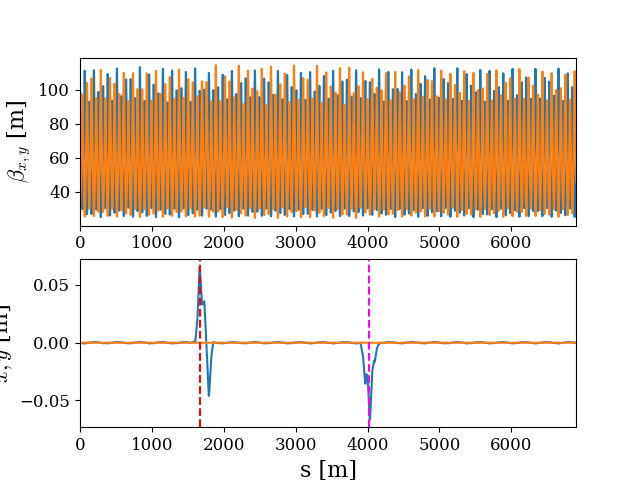

(0.0, 6900.0)

In [473]:
tw = line.twiss(continue_on_closed_orbit_error=True, method = '4d')

plt.figure()
ax1 = plt.subplot(2, 1, 1)
plt.plot(tw.s, tw.betx)
plt.plot(tw.s, tw.bety)
plt.ylabel(r"$\beta_{x,y}$ [m]")
plt.xlim(0,6900)
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
plt.plot(tw.s, tw.x)
plt.plot(tw.s, tw.y)
plt.axvline(tw["s", "zs.21633"], color="red", ls="--", label = "ZS entry")
plt.axvline(tw["s", "TECA.entry"], color="magenta", ls="--")
plt.ylabel(r"$x,y$ [m]")
plt.xlabel("s [m]")
plt.show()
plt.xlim(0,6900)

## Installing the septa and creating the beam

In [474]:
line.discard_tracker()
septa_names_with_apertures = install_septa(line, install_zs=False)
print(septa_names_with_apertures)

['tpst.21760_entry.sep', 'mst.21774.sep', 'mst.21779.sep', 'mst.21794.sep', 'mse.21832.sep', 'mse.21837.sep', 'mse.21852.sep', 'mse.21857.sep', 'mse.21872.sep']


In [475]:
n_part = 1000

x_norm   = np.random.normal(loc = 0, scale = 1, size=n_part)
px_norm =  np.random.normal(loc = 0, scale = 1, size=n_part)  # in between being channeled and not
#x_norm  = TECA.jaw * np.ones(n_part)
#px_norm = TECA.tilt * np.ones(n_part)
y_norm, py_norm = np.zeros(n_part), np.zeros(n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * deltaP_P

line.build_tracker()

N_EX = 10e-7 # REDUCED NORMALISED EMITTANCE BY A FACTOR 10 AS MASSIMO GIOVANNOZZI SUGGESTED, IT IMPOVES THE EFFICIENY BY 1% !!!

particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

particles_init = particles.copy()
#tw_lss2 = tw.rows['TECA.entry':'_end_point']

tw_lss2 = tw.rows[:]


The line has collective elements.
In the twiss computation collective elements are replaced by drifts


### Reference momentum change

In [476]:
line.discard_tracker()

num_turns = 10000

# Define the momentum increment per turn (Δp₀c)
#delta_p0c =  2000e9 / 10 * 23e-6  # Example: 450 GeV over 10 s with 23 μs revolution time
delta_p0c = - 0.6e9 / num_turns  # THE SPS ENERGY CAN GO UP TO 400.6 GeV SO I ASSUME 0.6 GeV DIVIDED BY 100 TURNS

# Create the ReferenceEnergyIncrease element
energy_increase = xt.ReferenceEnergyIncrease(Delta_p0c=delta_p0c)

# Append the energy increase element to the end of the line
line.append_element(energy_increase, name='energy_increase')

<Line  at 5270220496>

### Inserting the monitors

In [477]:
#PLACING ONLY TWO MONITORS TO SAVE TIME
# Convert Twiss table to DataFrame and set 'name' as index
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

# Remove tracker before inserting new elements
line.discard_tracker()

monitor_tun_number = 100

# INSERT THE FOLLOWING MONITORS IF YOU WANT TO GET THE PHASE SPACE PLOTS AT THE END OF THE SIMULATION

# Insert monitor only at 'TECA.exit'
monitor_teca = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
line.insert_element(name='TECA_monitor', element=monitor_teca, index='TECA.exit')
tw_lss2_df.loc['TECA.exit', 'monitors'] = monitor_teca

# Insert monitor only at 'tpst.21760_entry'
monitor_tpst = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
line.insert_element(name='TPST_monitor', element=monitor_tpst, index='tpst.21760_entry')
tw_lss2_df.loc['tpst.21760_entry', 'monitors'] = monitor_tpst

# Insert monitor only at tcsm.51932.
monitor_tcsm = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
line.insert_element(name='TCSM_monitor', element=monitor_tcsm, index='tcsm.51932.')
tw_lss2_df.loc['tcsm.51932.', 'monitors'] = monitor_tcsm

### Inserting TECA

In [478]:
line.discard_tracker()
#line.insert_element("extraction.crystal.TECS", TECS, at_s=line.get_table()['s', 'tecs.21602'] )
line.insert_element("extraction.crystal.TECA", TECA, at_s = line.get_table()['s', 'TECA.entry'] )

Slicing line:   0%|          | 0/4620 [00:00<?, ?it/s]

<Line  at 5270220496>

## MOving a lil bit the septum elements

In [479]:
# Move the blade_position of 'mst.21794.sep' down by 1 mm
element_name = 'mst.21794.sep'
line[element_name].interaction_process.blade_position += 0.002  # 1 mm = 0.001 m
print(f"New blade_position for {element_name}: {line[element_name].interaction_process.blade_position} m")

New blade_position for mst.21794.sep: 0.0444 m


In [480]:
element_name = 'mst.21774.sep'
line[element_name].interaction_process.blade_position -= 0.001  # 1 mm = 0.001 m
print(f"New blade_position for {element_name}: {line[element_name].interaction_process.blade_position} m")

New blade_position for mst.21774.sep: 0.03979 m


In [481]:
# element_name = 'mst.21779.sep'
line[element_name].interaction_process.blade_position += 0.001  # 1 mm = 0.001 m
print(f"New blade_position for {element_name}: {line[element_name].interaction_process.blade_position} m")

New blade_position for mst.21774.sep: 0.04079 m


# Tracking

In [482]:
#line.discard_tracker()
#line.build_tracker(_context=xo.ContextCpu())
context = xo.ContextCpu(omp_num_threads='auto')

particles = particles_init.copy()
line.track(
    particles,
    num_turns=num_turns,
    turn_by_turn_monitor=True,
    # freeze_longitudinal=True,
    time=True
)
if np.any(particles.state < 1):
    lost_particles = np.where(particles.state < 1)[0]
    print(f"Particles lost during tracking: {len(lost_particles)}")
else:
    print("No particles lost during tracking")
record = line.time_last_track

Particles lost during tracking: 1000


# Printing the losses

In [483]:
import numpy as np

# Get indices of lost particles
lost_particles = np.where(particles.state < 1)[0]

if len(lost_particles) > 0:
    print(f"Number of lost particles: {len(lost_particles)}")
    print("\nParticle loss locations:")

    # Get element names from the line
    element_names = line.element_names

    # Count losses per element
    loss_counts = {}
    for idx in lost_particles:
        lost_at = particles.at_element[idx]  # Index of element where the particle was lost
        lost_element_name = element_names[lost_at]
        loss_counts[lost_element_name] = loss_counts.get(lost_element_name, 0) + 1

    # Print where the particles were lost
    for element, count in loss_counts.items():
        print(f"{count} particles lost at element '{element}'")
else:
    print("No particles were lost during tracking")

Number of lost particles: 1000

Particle loss locations:
963 particles lost at element 'tt20.extraction'
31 particles lost at element 'tpst.21760_entry.sep'
1 particles lost at element 'qe.50202_aper'
5 particles lost at element 'extraction.crystal.TECA'


In [484]:
# Find indices of lost particles at 'tpst.21760_entry.sep'
lost_at_tpst = [
    idx for idx in np.where(particles.state < 1)[0]
    if line.element_names[particles.at_element[idx]] == 'tpst.21760_entry.sep'
]

if lost_at_tpst:
    print("Particles lost at tpst.21760_entry.sep:")
    lost_info = []
    for idx in lost_at_tpst:
        x_val = particles.x[idx]
        px_val = particles.px[idx]
        dpp_val = particles.delta[idx]
        lost_info.append({'idx': idx, 'x': x_val, 'px': px_val, 'dpp': dpp_val})
        print(f"Particle {idx}: x = {x_val:.6e}, px = {px_val:.6e}, dpp = {dpp_val:.6e}")
else:
    print("No particles lost at tpst.21760_entry.sep")

Particles lost at tpst.21760_entry.sep:
Particle 10: x = 4.033036e-02, px = 2.510190e-04, dpp = 4.568470e-04
Particle 42: x = 4.034941e-02, px = 2.522479e-04, dpp = 4.250153e-04
Particle 101: x = 4.384813e-02, px = 3.499871e-04, dpp = 1.682778e-04
Particle 159: x = 3.964356e-02, px = 2.293859e-04, dpp = 1.157059e-03
Particle 166: x = 3.984681e-02, px = 2.365016e-04, dpp = 6.954431e-04
Particle 172: x = 4.012244e-02, px = 2.425784e-04, dpp = 1.165309e-03
Particle 191: x = 3.990111e-02, px = 2.403102e-04, dpp = 6.084541e-04
Particle 224: x = 4.010068e-02, px = 2.292571e-04, dpp = 1.368602e-03
Particle 250: x = 4.207172e-02, px = 2.798223e-04, dpp = 1.324250e-03
Particle 251: x = 3.984873e-02, px = 2.437956e-04, dpp = 4.239175e-04
Particle 269: x = 4.367194e-02, px = 3.467520e-04, dpp = 4.869928e-05
Particle 292: x = 4.247030e-02, px = 3.066987e-04, dpp = 7.052886e-04
Particle 341: x = 4.086448e-02, px = 2.659252e-04, dpp = 8.190671e-04
Particle 404: x = 3.963757e-02, px = 2.210518e-04, d

In [485]:
# Find indices of lost particles at 'mst.21794.sep'
lost_at_mst = [
    idx for idx in np.where(particles.state < 1)[0]
    if line.element_names[particles.at_element[idx]] == 'mst.21794.sep'
]

if lost_at_mst:
    print("Particles lost at mst.21794.sep:")
    lost_info = []
    for idx in lost_at_mst:
        x_val = particles.x[idx]
        px_val = particles.px[idx]
        dpp_val = particles.delta[idx]
        lost_info.append({'idx': idx, 'x': x_val, 'px': px_val, 'dpp': dpp_val})
        print(f"Particle {idx}: x = {x_val:.6e}, px = {px_val:.6e}, dpp = {dpp_val:.6e}")
else:
    print("No particles lost at mst.21794.sep")

No particles lost at mst.21794.sep


# Phase space at TECA

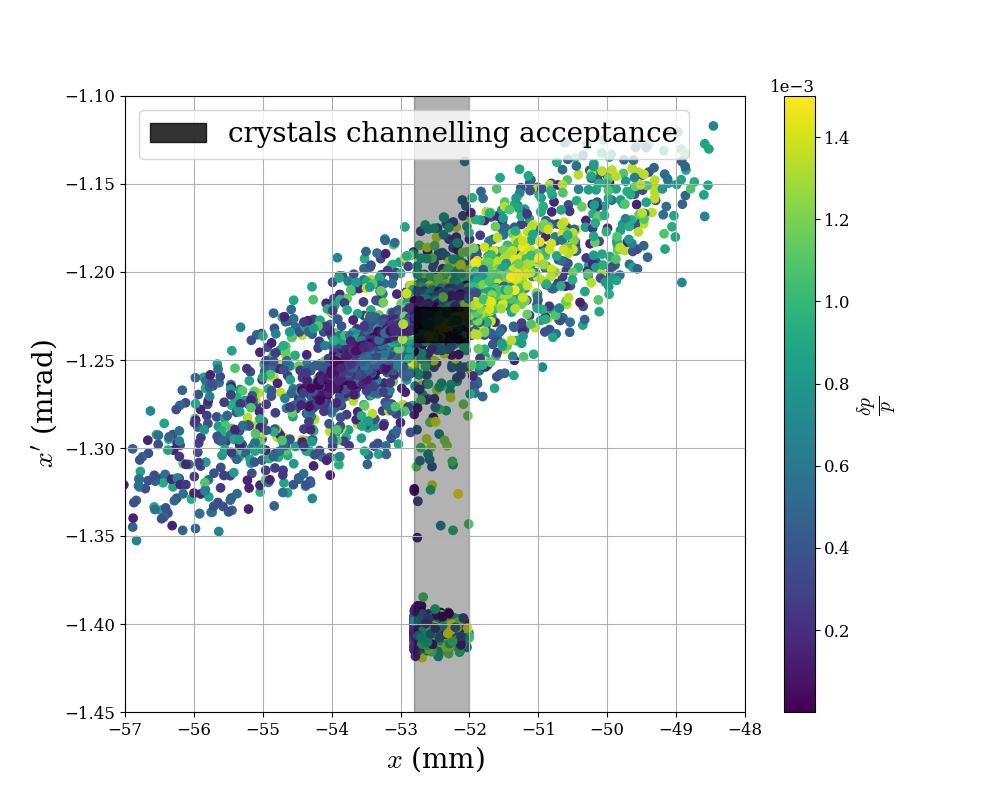

In [486]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TECA_entry = tw_lss2_df.loc['TECA.entry']
row_TECA_exit = tw_lss2_df.loc['TECA.exit']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)

for turn in range(monitor_tun_number):
    sc = ax.scatter(
        row_TECA_exit['monitors'].x[:, turn] * 1e3,  # Use data for x at the current turn
        row_TECA_exit['monitors'].px[:, turn] * 1e3,  # Use data for px at the current turn
        c=particles_init._delta,  # Use dpp values from particles_init._delta
        cmap='viridis'
    )
cbar = plt.colorbar(sc, label=r"$\frac{\delta p}{p}$ ")
cbar.ax.yaxis.label.set_size(20)

#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')

ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.8, label='crystals channelling acceptance')
ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], -100, +100, color='k', alpha=0.3)

#ax.plot([], [], 'k.', label='Particles at TECA entry')
#ax.plot([], [], 'b.', label='Particles after TECA')
#ax.set_title("Phase space at TECA over the last 100 turns", fontsize=20)
ax.legend(fontsize=20, loc = 'upper left')
ax.grid(True)

ax.set_xlim(-57, -48)
ax.set_ylim(-1.45, -1.1)

ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('teca_phase_space.png', bbox_inches='tight')

# Time evolution at TECA location

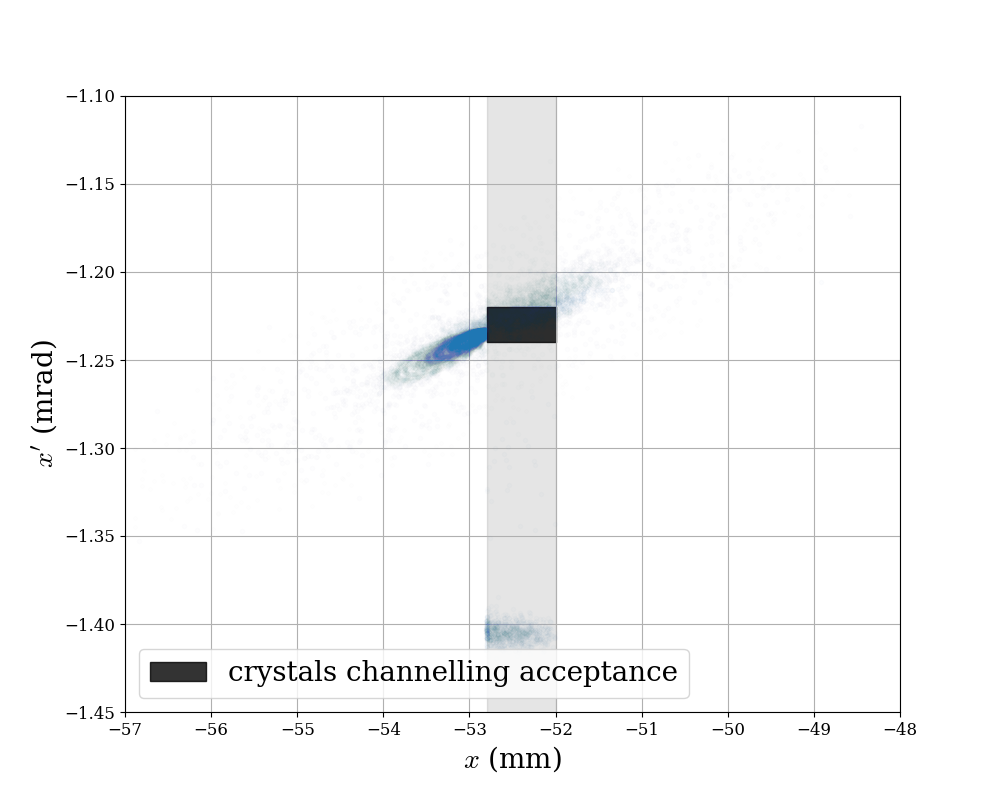

In [487]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TECA_entry = tw_lss2_df.loc['TECA.entry']
row_TECA_exit = tw_lss2_df.loc['TECA.exit']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)

for turn in range(monitor_tun_number):
    alpha_val = (turn + 1) / num_turns  # alpha increases from 0 to 1
    ax.plot(
        row_TECA_exit['monitors'].x[:, turn] * 1e3,
        row_TECA_exit['monitors'].px[:, turn] * 1e3,
        '.', 
        color='C0',
        alpha=alpha_val
    ) 

#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')

ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.8, label='crystals channelling acceptance')
ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], -100, +100, color='k', alpha=0.1)

#ax.plot([], [], 'k.', label='Particles at TECA entry')
#ax.plot([], [], 'b.', label='Particles after TECA')
#ax.set_title("Phase space at TECA over the last 100 turns", fontsize=20)
ax.legend(fontsize=20)
ax.grid(True)

ax.set_xlim(-57, -48)
ax.set_ylim(-1.45, -1.1)

ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('teca_phase_space.png', bbox_inches='tight')

# Phase space at TPST

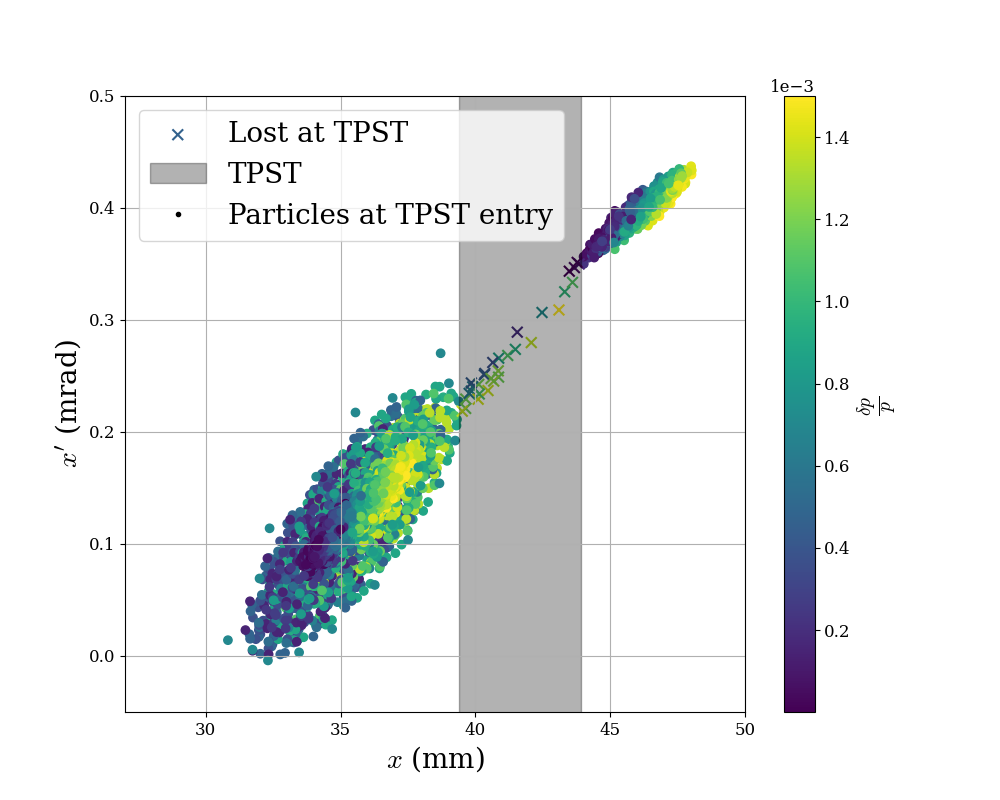

In [488]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TPST_entry = tw_lss2_df.loc['tpst.21760_entry']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

#ax.plot(row_TPST_entry['monitors'].x[:, :] * 1e3, row_TPST_entry['monitors'].px[:, :] * 1e3, 'k.', alpha=0.5)
for turn in range(monitor_tun_number):
    sc = ax.scatter(
        row_TPST_entry['monitors'].x[:, turn] * 1e3,  # Use data for x at the current turn
        row_TPST_entry['monitors'].px[:, turn] * 1e3,  # Use data for px at the current turn
        c=particles_init._delta,  # Use dpp values from particles_init._delta
        cmap='viridis'
    )
#plt.colorbar(sc, label=r"$\frac{\delta p}{p}$ ")
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)
cbar = plt.colorbar(sc, label=r"$\frac{\delta p}{p}$ ")
cbar.ax.yaxis.label.set_size(20)

# Plot the particles lost at tpst.21760_entry.sep
if lost_at_tpst:
    ax.scatter(
        [particles.x[idx] * 1e3 for idx in lost_at_tpst],    # x in mm
        [particles.px[idx] * 1e3 for idx in lost_at_tpst],   # px in mrad
        c=[particles.delta[idx] for idx in lost_at_tpst],    # dpp for color
        cmap='viridis',
        marker='x',
        s=60,
        label='Lost at TPST'
    )

# Plot the particles lost at mst.21794.sep
if lost_at_mst:
    ax.scatter(
        [particles.x[idx] * 1e3 for idx in lost_at_mst],    # x in mm
        [particles.px[idx] * 1e3 for idx in lost_at_mst],   # px in mrad
        c=[particles.delta[idx] for idx in lost_at_mst],    # dpp for color
        cmap='viridis',
        marker='x',
        s=60,
        label='Lost at TPST'
    )

#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')
element_name = 'tpst.21760_entry.sep'
x = line[element_name].interaction_process.blade_position
thickness = line[element_name].interaction_process.thickness
ax.fill_between([x*1e3, x*1e3 + thickness*1e3],-1, 1, color='k', alpha=0.3, label='TPST')

ax.plot([], [], 'k.', label='Particles at TPST entry')

#ax.set_title("Phase space at TECA over the last 100 turns", fontsize=20)
ax.legend(fontsize=20)
ax.grid(True)

ax.set_xlim(27, 50)
ax.set_ylim(-0.05, 0.5)
ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('tpst_phase_space.png', bbox_inches='tight')

# Time evolution at the TPST


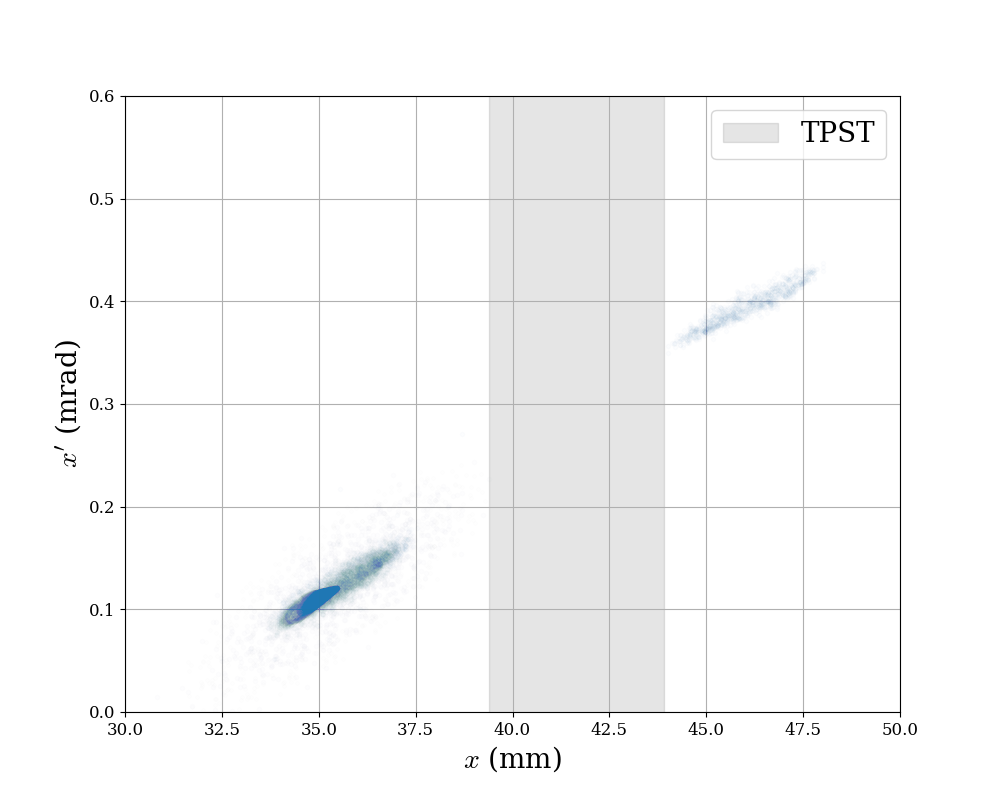

In [489]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TPST_entry = tw_lss2_df.loc['tpst.21760_entry']


fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)

for turn in range(monitor_tun_number):
    alpha_val = (turn + 1) / num_turns  # alpha increases from 0 to 1
    ax.plot(
        row_TPST_entry['monitors'].x[:, turn] * 1e3,
        row_TPST_entry['monitors'].px[:, turn] * 1e3,
        '.', 
        color='C0',
        alpha=alpha_val
    ) 

#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')
element_name = 'tpst.21760_entry.sep'
x = line[element_name].interaction_process.blade_position
thickness = line[element_name].interaction_process.thickness
ax.fill_between([x*1e3, x*1e3 + thickness*1e3],-1, 1, color='k', alpha=0.1, label='TPST')

#ax.plot([], [], 'k.', label='Particles at TECA entry')
#ax.plot([], [], 'b.', label='Particles after TECA')
#ax.set_title("Phase space at TECA over the last 100 turns", fontsize=20)
ax.legend(fontsize=20)
ax.grid(True)

ax.set_xlim(30, 50)
ax.set_ylim(0, 0.6)

ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('teca_phase_space.png', bbox_inches='tight')

# Phase space at the TCSM

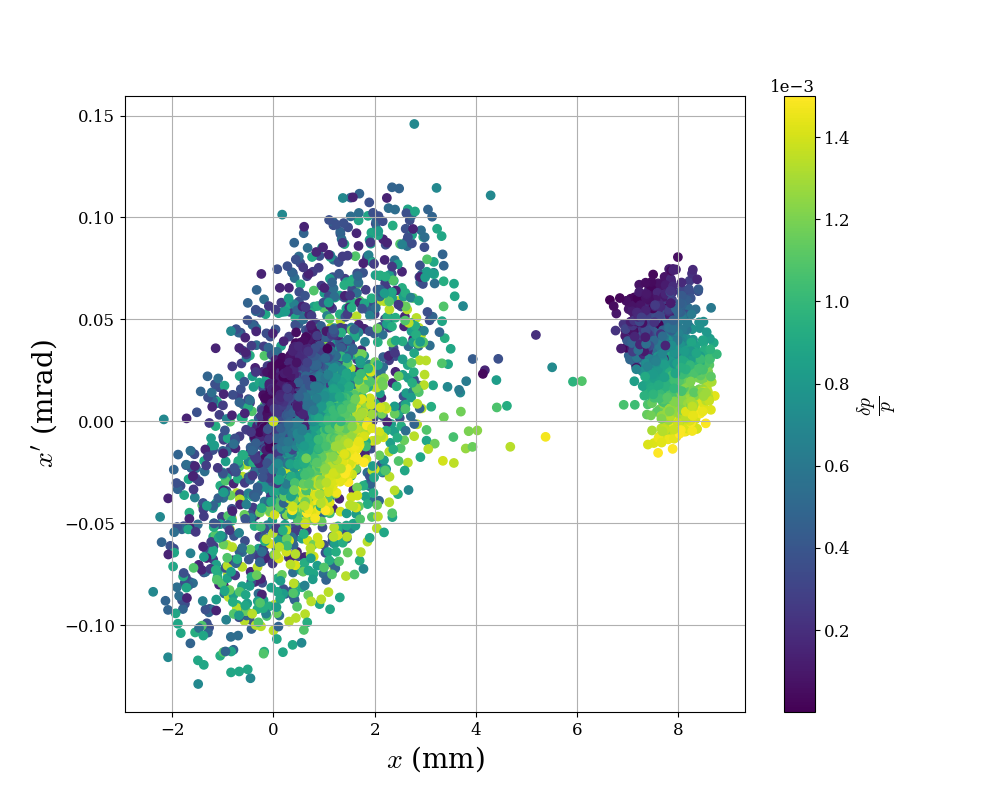

In [490]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TCSM = tw_lss2_df.loc['tcsm.51932.']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)

for turn in range(monitor_tun_number):
    sc = ax.scatter(
        row_TCSM['monitors'].x[:, turn] * 1e3,  # Use data for x at the current turn
        row_TCSM['monitors'].px[:, turn] * 1e3,  # Use data for px at the current turn
        c=particles_init._delta,  # Use dpp values from particles_init._delta
        cmap='viridis'
    )
cbar = plt.colorbar(sc, label=r"$\frac{\delta p}{p}$ ")
cbar.ax.yaxis.label.set_size(20)

# You can add acceptance/geometry overlays here if needed

#ax.legend(fontsize=20)
ax.grid(True)

# ax.set_xlim(-5, 15)
# ax.set_ylim(-0.15, 0.15)

ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('tcsm_phase_space.png', bbox_inches='tight')


